# PGC308A — Task III: Estimativa de Conformidade ao SLA (Regressão Logística)

Classificar se o serviço **conforma** ao SLA (`DispFrames >= 18` fps) ou **viola** o SLA, usando estatísticas do servidor (X).

- Split **70% treino** / **30% teste** (mesmo critério da Task II)
- Métrica: **ERR** = 1 − (TP + TN) / m (precisa ser < 15%)
- Classificadores C₁…C₅ com subconjuntos de treino: 50, 500, 1000, 1500, 2520

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, RANDOM_STATE, RESULTS_DIR, SLA_THRESHOLD_FPS, TRAIN_SIZES
from src.data import feature_columns, load_trace, target_column
from src.labels import rename_classification_results, rename_coefficient_table
from src.metrics import classification_error, confusion_counts
from src.splits import sample_training_subset, train_test_split_sla

FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
df = load_trace()
features = feature_columns()
target = target_column()

train_df, test_df, x_train, y_train, x_test, y_test, y_reg_test, _ = train_test_split_sla(
    df, features, target
)

resumo_dados = pd.DataFrame(
    {
        "Conjunto": ["Treino", "Teste"],
        "Observações": [len(train_df), len(test_df)],
        "Taxa de conformidade ao SLA (%)": [
            round(y_train.mean() * 100, 2),
            round(y_test.mean() * 100, 2),
        ],
        "Significado": [
            "Percentual de amostras em que DispFrames >= 18 fps no treino",
            "Percentual de amostras em que DispFrames >= 18 fps no teste",
        ],
    }
)

print(f"SLA: conforme se taxa de frames >= {SLA_THRESHOLD_FPS} fps")
resumo_dados

SLA: conforme se taxa de frames >= 18 fps


,Conjunto,Observações,Taxa de conformidade ao SLA (%),Significado
0,Treino,2520,52.14,Percentual de amostras em que DispFrames >= 18...
1,Teste,1080,50.46,Percentual de amostras em que DispFrames >= 18...


## 1. Classificadores C₁…C₅ — coeficientes, tempo e ERR

In [3]:
def train_classifier(n_train: int) -> dict:
    subset = sample_training_subset(train_df, n_train, random_state=RANDOM_STATE)
    x_sub = subset[features].to_numpy()
    y_sub = (subset[target].to_numpy() >= SLA_THRESHOLD_FPS).astype(int)

    clf = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
    t0 = time.perf_counter()
    clf.fit(x_sub, y_sub)
    train_ms = (time.perf_counter() - t0) * 1000

    y_pred = clf.predict(x_test)
    err = classification_error(y_test, y_pred)
    return {
        "n_train": n_train,
        "classifier": clf,
        "coefficients": clf.coef_[0],
        "intercept": clf.intercept_[0],
        "train_time_ms": train_ms,
        "err": err,
        "y_pred": y_pred,
        "confusion": confusion_counts(y_test, y_pred),
    }


classifiers = [train_classifier(n) for n in TRAIN_SIZES]

results_df = pd.DataFrame([
    {
        "classifier": f"C{i + 1}",
        "n_train": c["n_train"],
        "train_time_ms": c["train_time_ms"],
        "err": c["err"],
        "err_pct": c["err"] * 100,
        "accurate": c["err"] < 0.15,
        **c["confusion"],
    }
    for i, c in enumerate(classifiers)
])

rename_classification_results(results_df).round(4)

,Classificador,Observações no treino,Tempo de treino (ms),Erro de classificação (ERR),ERR (%),Acurado (< 15%)?,Verdadeiros positivos (VP),Verdadeiros negativos (VN),Falsos positivos (FP),Falsos negativos (FN)
0,C1,50,118.9537,0.1537,15.3704,Não,438,476,59,107
1,C2,500,275.0919,0.1296,12.9630,Sim,465,475,60,80
2,C3,1000,262.2902,0.1287,12.8704,Sim,464,477,58,81
3,C4,1500,1373.2189,0.1139,11.3889,Sim,479,478,57,66
4,C5,2520,2526.5507,0.1111,11.1111,Sim,486,474,61,59


In [4]:
coef_rows = []
for i, c in enumerate(classifiers):
    row = {"classifier": f"C{i + 1}", "n_train": c["n_train"]}
    for feat, coef in zip(features, c["coefficients"]):
        row[feat] = coef
    row["intercept"] = c["intercept"]
    coef_rows.append(row)

coef_table = pd.DataFrame(coef_rows).set_index("classifier")
coef_table_pt = rename_coefficient_table(coef_table)
coef_table_pt.round(6)

,Observações no treino,CPU ociosa (%),Memória usada (%),Taxa de criação de processos (/s),Taxa de troca de contexto (/s),File handles em uso,Taxa de interrupções (/s),Média de carga — 1 min,Sockets TCP em uso,Taxa de liberação de páginas (/s),Intercepto (Θ₀)
Classificador,,,,,,,,,,,
C1,50,0.001587,0.629157,-0.293549,-0.001244,-0.044822,0.006691,-0.387684,0.563922,0.000500,-0.002375
C2,500,-0.079522,-0.032094,-0.073961,-0.000050,0.003731,0.000434,-0.086385,-0.059317,-0.000010,0.001014
C3,1000,-0.016405,-0.056249,-0.038447,0.000026,0.001966,0.000616,-0.089589,-0.078021,-0.000012,0.001367
C4,1500,-0.079016,-0.105971,-0.016298,-0.000057,-0.002493,0.000139,-0.055016,-0.059050,-0.000012,25.499481
C5,2520,-0.097602,-0.103568,-0.007932,-0.000065,-0.001492,0.000153,-0.058250,-0.065134,-0.000014,23.627035


### 1(d) ERR e tempo de treino vs tamanho do conjunto de treino

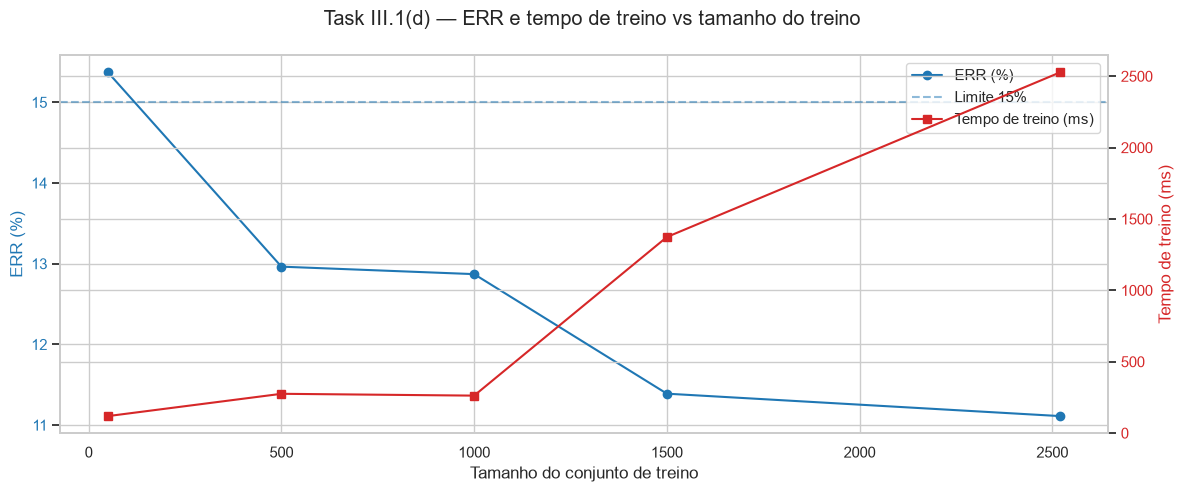

In [5]:
fig, ax1 = plt.subplots()

color_err = "tab:blue"
color_time = "tab:red"

ax1.plot(results_df["n_train"], results_df["err_pct"], "o-", color=color_err, label="ERR (%)")
ax1.axhline(15, color=color_err, linestyle="--", alpha=0.5, label="Limite 15%")
ax1.set_xlabel("Tamanho do conjunto de treino")
ax1.set_ylabel("ERR (%)", color=color_err)
ax1.tick_params(axis="y", labelcolor=color_err)

ax2 = ax1.twinx()
ax2.plot(results_df["n_train"], results_df["train_time_ms"], "s-", color=color_time, label="Tempo de treino (ms)")
ax2.set_ylabel("Tempo de treino (ms)", color=color_time)
ax2.tick_params(axis="y", labelcolor=color_time)

fig.suptitle("Task III.1(d) — ERR e tempo de treino vs tamanho do treino")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task_iii_1d_err_train_time.png", dpi=150)
plt.show()

### 1(e) Série temporal no teste — classificação do modelo mais acurado

Classificador mais acurado: C5 (ERR = 11.1111%)


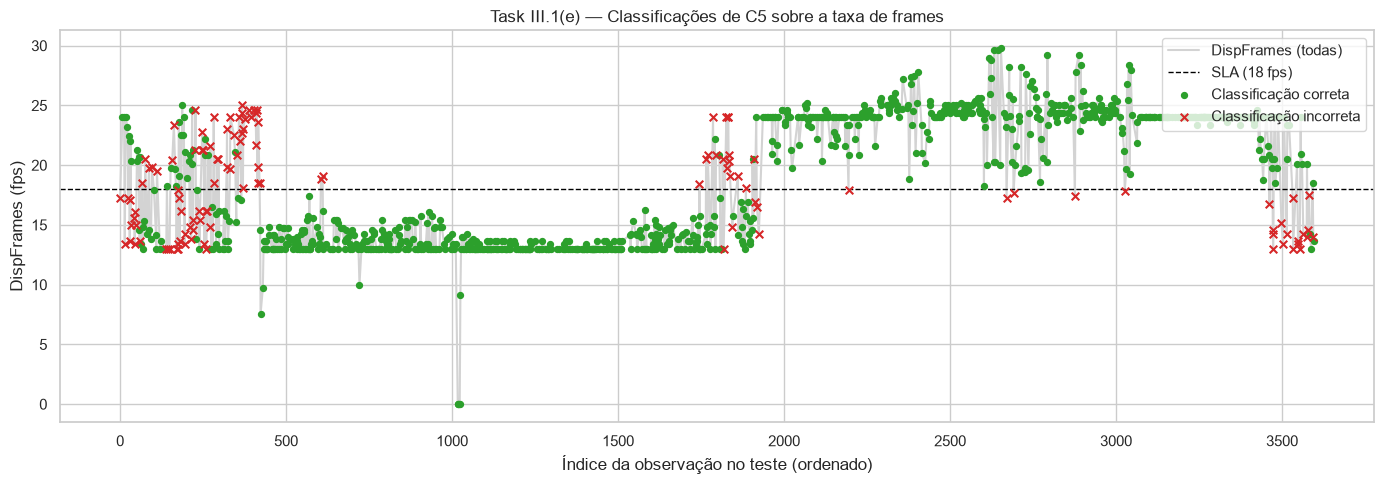

In [6]:
best_idx = results_df["err"].idxmin()
best = classifiers[best_idx]
best_name = results_df.loc[best_idx, "classifier"]
print(f"Classificador mais acurado: {best_name} (ERR = {best['err']:.4%})")

test_plot = test_df.sort_index().copy()
y_pred_best = best["classifier"].predict(test_plot[features].to_numpy())
y_true_best = (test_plot[target].to_numpy() >= SLA_THRESHOLD_FPS).astype(int)
correct = y_pred_best == y_true_best

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_plot.index, test_plot[target], color="lightgray", linewidth=1.5, label="DispFrames (todas)")
ax.axhline(SLA_THRESHOLD_FPS, color="black", linestyle="--", linewidth=1, label=f"SLA ({SLA_THRESHOLD_FPS} fps)")

ax.scatter(
    test_plot.index[correct],
    test_plot[target].to_numpy()[correct],
    marker="o",
    s=18,
    c="tab:green",
    label="Classificação correta",
    zorder=3,
)
ax.scatter(
    test_plot.index[~correct],
    test_plot[target].to_numpy()[~correct],
    marker="x",
    s=30,
    c="tab:red",
    label="Classificação incorreta",
    zorder=4,
)

ax.set_xlabel("Índice da observação no teste (ordenado)")
ax.set_ylabel("DispFrames (fps)")
ax.set_title(f"Task III.1(e) — Classificações de {best_name} sobre a taxa de frames")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task_iii_1e_timeseries_classification.png", dpi=150)
plt.show()

In [7]:
rename_classification_results(results_df).round(4).to_csv(
    RESULTS_DIR / "task_iii_results.csv", index=False
)
coef_table_pt.round(6).to_csv(RESULTS_DIR / "task_iii_coefficients.csv")

print("Resultados salvos em results/")

Resultados salvos em results/
